In [1]:
%config InlineBackend.figure_formats = ['svg']
import pandas as pd
import seaborn as sns
from glob import glob
sns.set_theme(style="ticks", font="Linux Biolinum O", font_scale=1.2)

frames = [pd.read_csv(data) for data in glob('../targeted-lost_*.csv')]
data = pd.concat(frames, ignore_index=True)

def classify(r):
    if r['fragment_k'] == 1:
        return "Replicated"
    else:
        return "Vault$_{(" + str(int(r['chunk_n'])) + ", 8)}$"

data['Protocol'] = data.apply(classify, axis=1)
data['targeted_portion'] = data['targeted'] / (100 * 1000)
data = data.sort_values(by=["data_lost"])
data

,churn_rate,node_count,duration,faulty_rate,object_count,chunk_n,chunk_k,fragment_n,fragment_k,cache_sec,targeted_count,data_lost,targeted,repair,alive_count,Protocol,targeted_portion
91,4,100000,315360000,0,100,12,8,80,32,0,100,0,0,963794.500,80,"Vault$_{(12, 8)}$",0.00000
124,4,100000,315360000,0,100,12,8,80,32,0,50,0,0,963706.500,80,"Vault$_{(12, 8)}$",0.00000
122,4,100000,315360000,0,100,100,100,3,1,4294967295,0,0,0,12003.280,3,Replicated,0.00000
287,4,100000,315360000,0,100,14,8,80,32,0,0,0,0,1124398.250,80,"Vault$_{(14, 8)}$",0.00000
664,4,100000,315360000,0,100,12,8,80,32,0,150,0,0,963751.000,80,"Vault$_{(12, 8)}$",0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,4,100000,315360000,0,100,10,8,80,32,0,850,100,49235,802990.000,79,"Vault$_{(10, 8)}$",0.49235
144,4,100000,315360000,0,100,10,8,80,32,0,950,100,53237,802928.500,80,"Vault$_{(10, 8)}$",0.53237
142,4,100000,315360000,0,100,10,8,80,32,0,650,100,40568,803049.375,79,"Vault$_{(10, 8)}$",0.40568
96,4,100000,315360000,0,100,100,100,3,1,4294967295,750,100,2228,11993.200,3,Replicated,0.02228


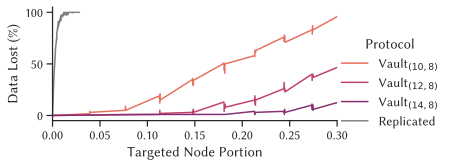

In [2]:
palette = sns.color_palette('flare', n_colors=3)
sns.relplot(data=data, 
    kind="line",
    x="targeted_portion", y="data_lost", hue="Protocol",
    # sort=True,
    hue_order=['Vault$_{(10, 8)}$', 'Vault$_{(12, 8)}$', 'Vault$_{(14, 8)}$', 'Replicated'],
    palette=[*palette, 'gray'],
    markers='*',
    height=2.56, aspect=2.) \
.set_xlabels("Targeted Node Portion") \
.set_ylabels("Data Lost (%)") \
.set(xlim=(0, 0.3)) \
.savefig("../../graphs/targeted-lost.pdf")